# Gaussian-beam pipeline: physics -> SymPy -> features -> ML -> C

A research notebook exercising the full `photonics_ml_pipeline` stack: derive the beam
width symbolically, verify it numerically, extract features, train a PyTorch classifier,
and generate portable C from the finalized equation.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, torch, sympy as sp
import matplotlib.pyplot as plt
from physics.symbolic import gaussian_beam_width
from physics.gaussian_beam import GaussianBeam
from feature_extraction.features import extract_features
from ml.dataset import BeamFeatureDataset
from ml.train import train_model
from ml.inference import predict, confusion_matrix
from c_codegen.generator import generate_c
sp.init_printing()
print('ready')

ready


## 1-3. Theory, equations, SymPy derivation
$w(z)=w_0\sqrt{1+(z/z_R)^2}$, $z_R=\pi w_0^2/\lambda$. SymPy differentiates it for us.

In [2]:
bw = gaussian_beam_width()
grad = bw.gradient()
print('w(z) =', bw.expr)
print('dw/dz =', sp.simplify(grad[0]))

w(z) = w0*sqrt(z**2/zR**2 + 1)
dw/dz = w0*z/(zR*sqrt(z**2 + zR**2))


## 4-5. Numerical verification and plot

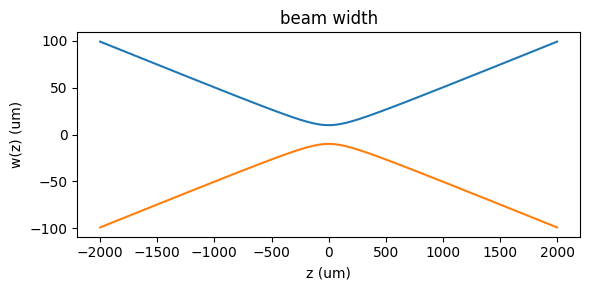

In [3]:
beam = GaussianBeam(1.55, 10.0)
z = np.linspace(-2000, 2000, 256)
w = beam.width_um(z)
f = bw.lambdify('numpy')
assert np.allclose(w, f(z, beam.waist_um, beam.rayleigh_range_um))
plt.figure(figsize=(6,3)); plt.plot(z, w); plt.plot(z, -w)
plt.xlabel('z (um)'); plt.ylabel('w(z) (um)'); plt.title('beam width'); plt.tight_layout(); plt.show()

## 6-7. Feature extraction and Torch classifier

In [4]:
ds = BeamFeatureDataset(n_samples=600, seed=0)
res = train_model(ds, input_dim=ds.feature_dim, n_classes=ds.n_classes, epochs=40, seed=0)
print('validation accuracy =', round(res.val_accuracy, 3))
X = torch.stack([ds[i][0] for i in range(len(ds))])
y = torch.stack([ds[i][1] for i in range(len(ds))])
cm = confusion_matrix(y, predict(res.model, X), ds.n_classes)
print('confusion matrix:\n', cm)

validation accuracy = 1.0
confusion matrix:
 [[200   0   0]
 [  0 200   0]
 [  0   0 200]]


## 8. Generated C from the finalized equation

In [5]:
print(generate_c(bw).source)

#include <math.h>
#include "beam_width.h"

double beam_width(double z, double w0, double zR) {
    return w0*sqrt(pow(z, 2)/pow(zR, 2) + 1);
}



## 9. Conclusions
One symbolic model flows end to end: SymPy derives and verifies it, physics generates
features, PyTorch classifies beams with high accuracy, and portable C is emitted for
embedded deployment -- no GPU required.